In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'
import pickle

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [8]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
az.plot_kde(data["caps"].values, rug=True)
plt.yticks([0], alpha=0);

NameError: name 'data' is not defined

In [58]:
fig = px.histogram(data, x="caps", color='session',
                   histnorm='probability',
                   orientation='v',
                   labels={'draws': 'DTD',
                            'acc': 'Response'},
                   barmode='overlay',
                   width=1733,
                   height=900)

fig.show()

In [9]:
data = pd.read_csv("data_bt_dem.csv").dropna()
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)


In [10]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()

hr_bt_capsx= pm.Model(coords=coords) 

with hr_bt_capsx:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=median_dtd, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", 5)

    mu_b_tms = pm.Normal("mu_b_tms", mu=0.0, sigma=10)
    sigma_b_tms = pm.HalfNormal("sigma_b_tms", 10)
    
    mu_b_caps = pm.Normal("mu_b_caps", mu=0.0, sigma=10)
    sigma_b_caps = pm.HalfNormal("sigma_b_caps", 10)
    
    mu_b_capsxtms = pm.Normal("mu_b_capsxtms", mu=0.0, sigma=10)
    sigma_b_capsxtms = pm.HalfNormal("sigma_b_capsxtms", 10)
    
    # Intercept for each participant, distributed around group mean mu_a
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b_tms = pm.Normal("b_tms", mu=mu_b_tms, sigma=sigma_b_tms, dims="participant")
    b_caps = pm.Normal("b_caps", mu=mu_b_caps, sigma=sigma_b_caps, dims="participant")
    b_capsxtms = pm.Normal("b_capsxtms", mu=mu_b_capsxtms, sigma=sigma_b_capsxtms, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)
    
        # Starting values for problematic parameters
    start = {
        "sigma_a": 10,    
        "sigma_b_tms": 10,
        "sigma_b_caps": 10 ,
        "sigma_b_capsxtms": 10 # Set a specific starting value for the standard deviation
    }


    draws_est_capsx = a[participant_idx] +b_tms[participant_idx] * data.session.values+ b_caps[participant_idx]* data.caps.values+ b_capsxtms[participant_idx]* data.session.values * data.caps.values

    # Data likelihood
    draws_like_capsx = pm.Poisson(
        "draws_like_capsx", mu=draws_est_capsx, observed=data.draws, dims="obs_id",testval=median_dtd
    )
    
    

In [11]:
with hr_bt_capsx:
     hr_bt_trace_capsx = pm.sample(10000,tune=10000, target_accept=0.99, return_inferencedata=True,
                                   start=start)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b_capsxtms, b_caps, b_tms, a, sigma_b_capsxtms, mu_b_capsxtms, sigma_b_caps, mu_b_caps, sigma_b_tms, mu_b_tms, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 55513 seconds.


0, dim: obs_id, 1357 =? 1357


There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
The chain reached the maximum tree depth. Increase max_treedepth, increase target_accept or reparameterize.
There were 118 divergences after tuning. Increase `target_accept` or reparameterize.
The chain reached the maximum tree depth. Increase max_treedepth, increase target_accept or reparameterize.
There were 35 divergences after tuning. Increase `target_accept` or reparameterize.
There were 16 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.


In [6]:
pm.model_to_graphviz(hr_bt_capsx)

NameError: name 'hr_bt_capsx' is not defined

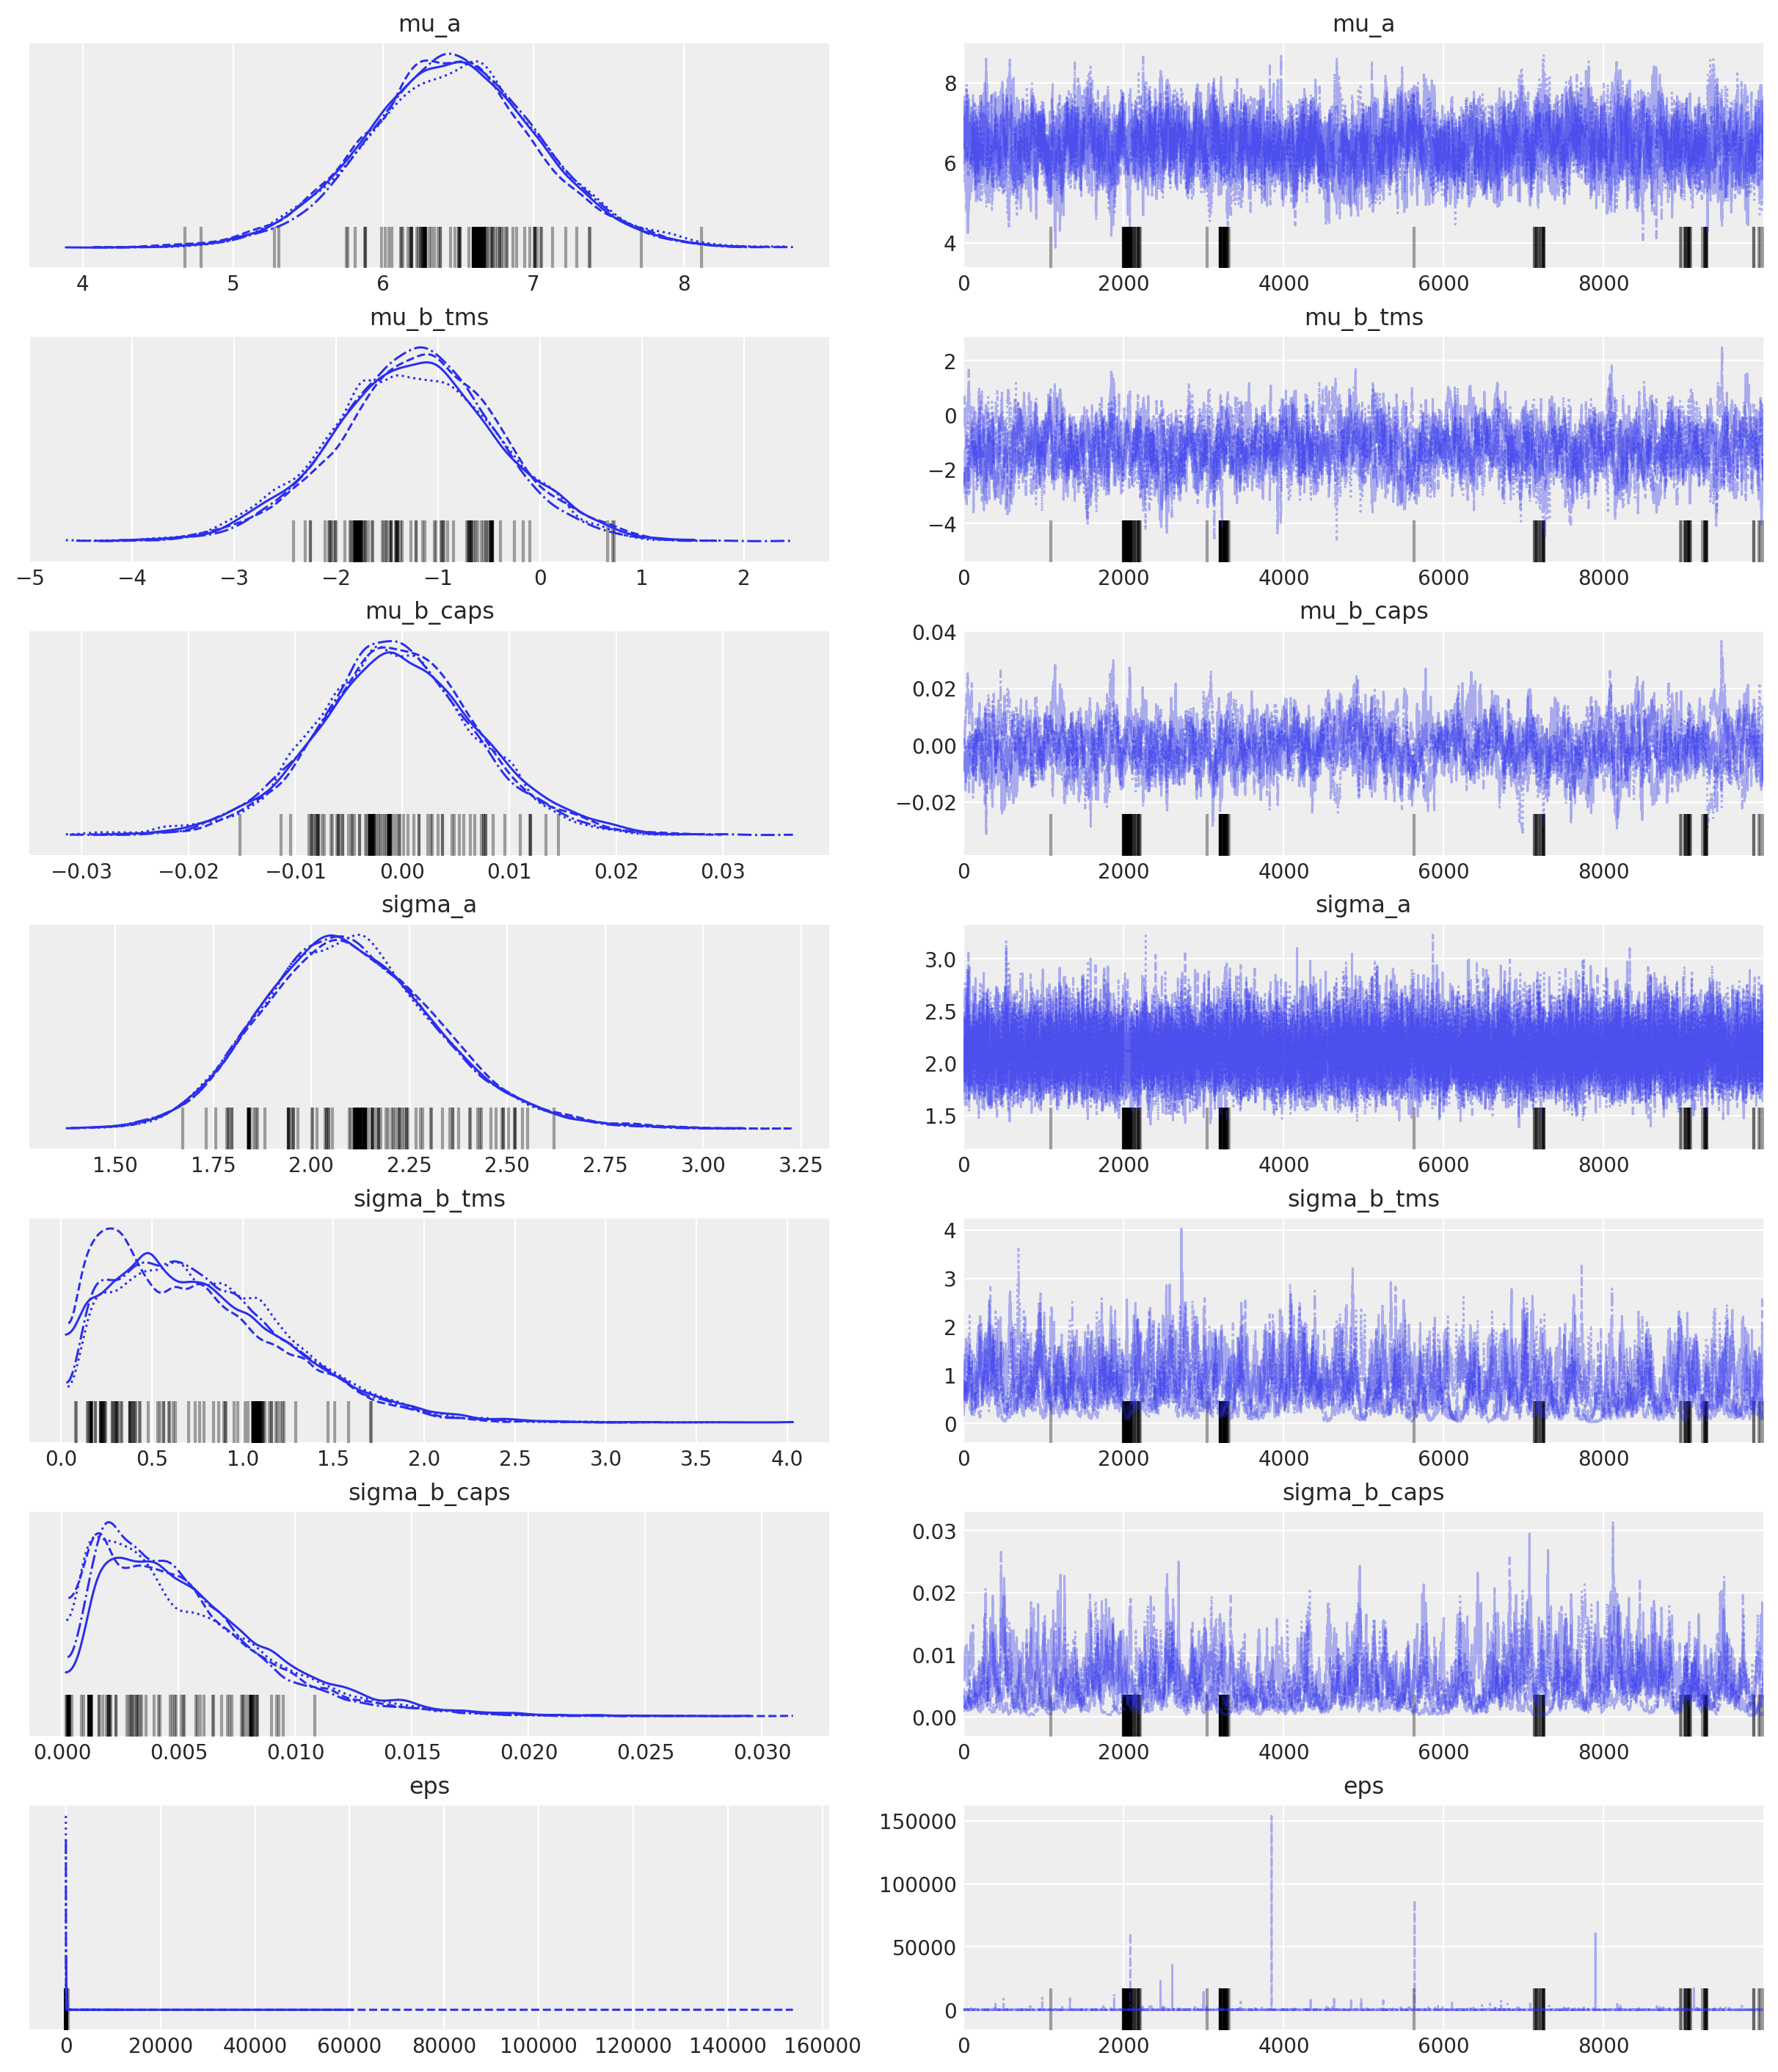

In [12]:
az.plot_trace(hr_bt_trace_capsx, var_names=["mu_a", "mu_b_tms","mu_b_caps",  "sigma_a", "sigma_b_tms", "sigma_b_caps","eps"]);

In [13]:
import pickle

# Save the model
with open('hr_dtd_tms_caps.pkl', 'wb') as file:
    pickle.dump(hr_bt_capsx, file)
    
hr_bt_trace_capsx.to_netcdf('hr_dtd_tms_caps.nc', compress=False)

'hr_dtd_tms_caps.nc'

In [3]:
# Load the model from the pickled file
with open('hr_dtd_tms_caps.pkl', 'rb') as file:
    hr_null = pickle.load(file)

hr_bt_trace_capsx = az.from_netcdf('hr_dtd_tms_caps.nc')


In [14]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_bt_trace_capsx.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_bt_trace_capsx).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_bt_trace_capsx).waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:           ()
Data variables:
    draws_like_capsx  float64 -1.097e+08
Effective number of parameters (p_waic): 31.229986320489694
WAIC: -2759.1701280497155


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



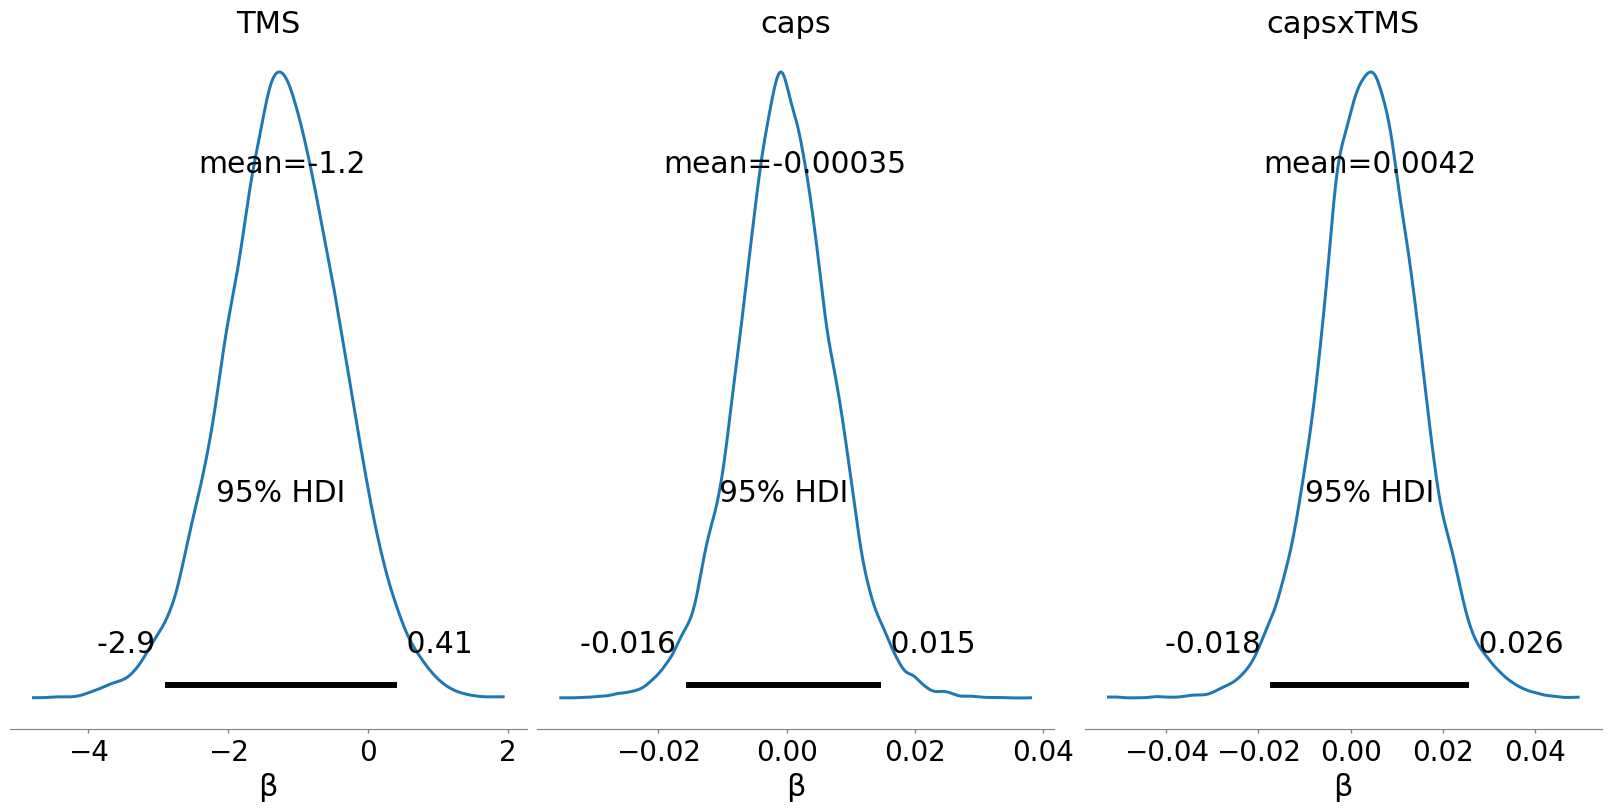

<Figure size 1600x800 with 0 Axes>

In [7]:
plot=az.plot_posterior(hr_bt_trace_capsx, var_names=["mu_b_tms", "mu_b_caps","mu_b_capsxtms"],
                       grid={3,1},
                       hdi_prob=0.95,
                       textsize=20, 
                       figsize={16, 8});                     

# Set the DPI for high resolution
dpi = 300

# Get the axes from the plot
axes = plot.ravel()

# Create a new Figure and specify the spacing between subplots
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(3, 1, hspace=0.4)  # Customize hspace as needed

# Add the existing axes to the new Figure

for i in range(3):
    ax = axes[i]
    ax.set_xlabel("β",fontsize=22)  # Set the custom y-axis label here

# Set the titles for each subplot
titles = ["TMS", "caps", "capsxTMS"]

# Loop through each subplot and set the title
for i, ax in enumerate(plot.ravel()):
    ax.set_title(titles[i],fontsize=22)

# Get the figure object
fig = plot.ravel()[0].figure

# Save the image with high resolution
fig.savefig("study2_mu_BTb_capsxtms_traces.png", dpi=dpi)



In [15]:
stat_tms_reg_capsx=pm.summary(hr_bt_trace_capsx)
stat_tms_reg_capsx


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.453,0.582,5.332,7.542,0.025,0.018,552.0,1634.0,1.01
mu_b_tms,-1.230,0.817,-2.783,0.312,0.039,0.028,427.0,1264.0,1.00
mu_b_caps,-0.001,0.008,-0.015,0.014,0.000,0.000,427.0,879.0,1.01
mu_b_capsxtms,0.004,0.011,-0.016,0.025,0.001,0.000,366.0,984.0,1.01
a[0],5.556,1.568,2.683,8.591,0.025,0.018,4056.0,9009.0,1.00
...,...,...,...,...,...,...,...,...,...
sigma_a,2.101,0.223,1.694,2.524,0.002,0.002,10179.0,17900.0,1.00
sigma_b_tms,0.775,0.480,0.034,1.606,0.026,0.018,267.0,398.0,1.03
sigma_b_caps,0.005,0.004,0.000,0.012,0.000,0.000,274.0,292.0,1.01
sigma_b_capsxtms,0.007,0.005,0.000,0.017,0.000,0.000,219.0,259.0,1.02


In [75]:
b_mu_reg_capsx=stat_tms_reg_capsx.loc['mu_b_capsx']['mean']
b_sigma_reg_capsx=stat_tms_reg_capsx.loc['mu_b_capsx']['sd']

In [76]:
print ("Beta caps =/0") 
b_capsx=NormalDist(mu=b_mu_reg_capsx, sigma=b_sigma_reg_capsx).overlap(NormalDist(mu=0, sigma=b_sigma_reg_capsx))
print (b_capsx)

Beta TMS =/0
0.5639914206179697


In [32]:
with hr_bt_capsx:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace_capsx, var_names=["a","b_capsx","draws_like"]
    )

<AxesSubplot:xlabel='draws_like / draws_like'>

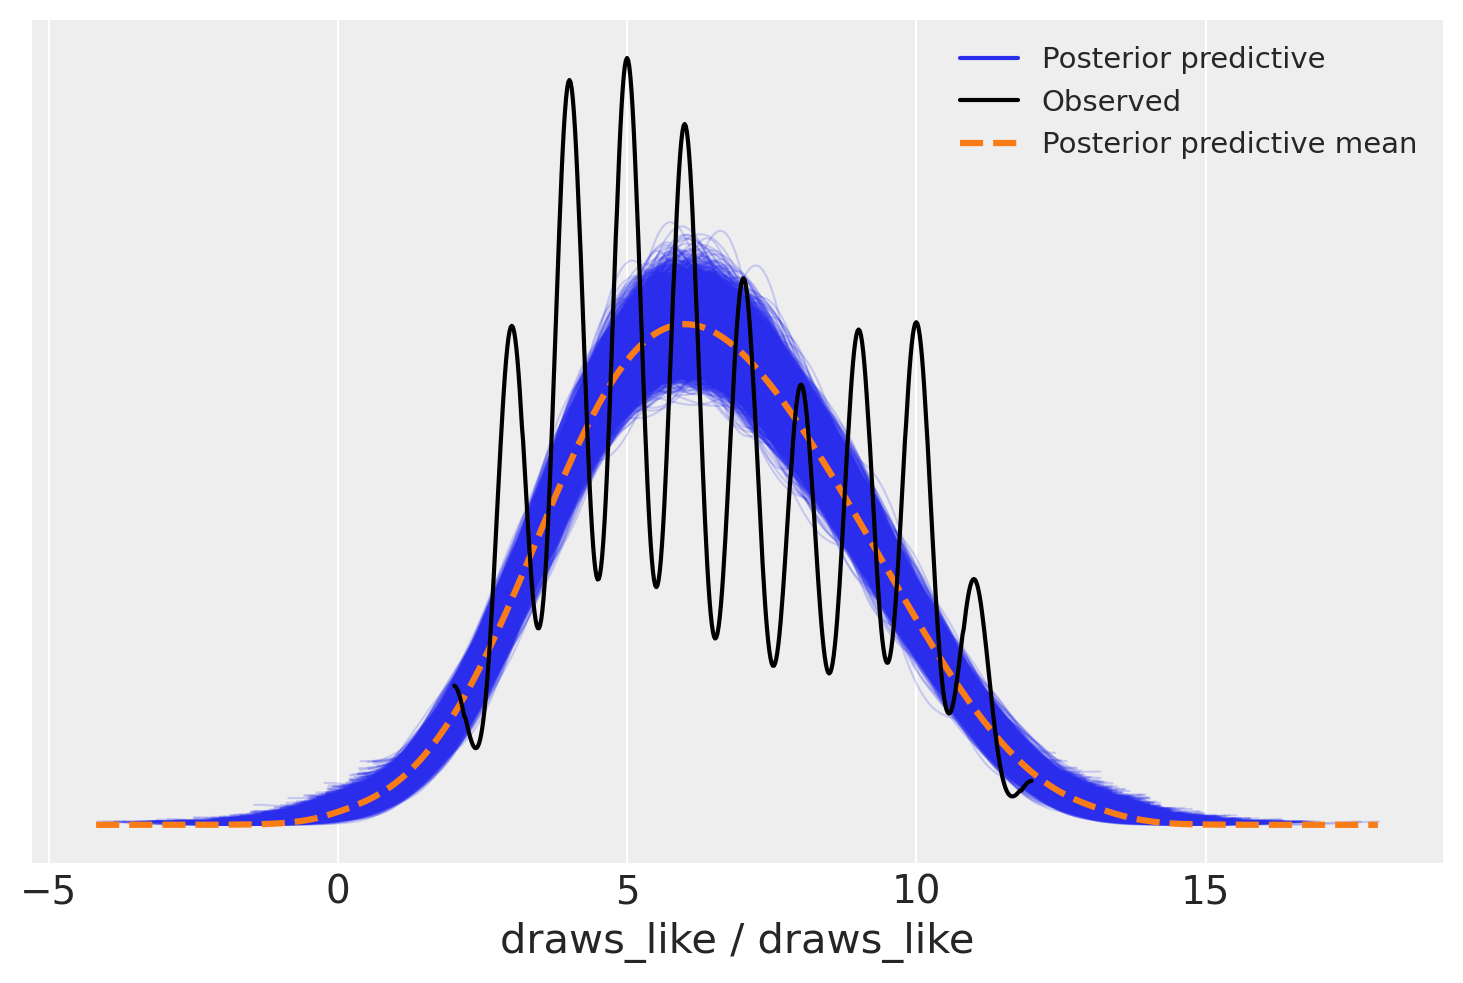

In [33]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt_capsx))

In [54]:
az.plot_trace(hr_bt_trace_capsx, var_names=["b_capsx"], coords={"participant": participant});


KeyError: 'var names: "[\'b_pdix\'] are not present" in dataset'

In [9]:
# Load the model from the pickled file
with open('hr_conf_null.pkl', 'rb') as file:
    hr_null = pickle.load(file)

hr_null_trace = az.from_netcdf('hr_null_trace.nc')


In [10]:
compare_dict = {"caps": hr_bt_trace_capsx, "null": hr_null_trace}
az.compare(compare_dict)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:145: UserWarning:

The default method used to estimate the weights for each model,has changed from BB-pseudo-BMA to stacking

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:876: RuntimeWarning:

overflow encountered in exp

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning:

overflow encountered in reduce

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:781: UserWarning:

rename 'sample' to 'sample' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:212: FutureWarning:

The frame.append method is deprecated a

ValueError: The number of observations should be the same across all models